# The Honest Validator

Most SMILES validators answer *"can this string be parsed into a molecule?"*. The canonical answer — RDKit's — is generous: 99.98% of the SMILES in common chemistry datasets (MOSES, MUV, QM9, ZINC250k, ClinTox, SIDER, Tox21, Mutagenicity) are accepted. That generosity is intentional; RDKit is a chemistry toolkit, not a gatekeeper.

This notebook frames our parser as a different kind of validator. Beyond the grammar check, it enforces two **structural** chemistry rules at parse time:

1. **Valency via the octet rule** — a non-ring, non-aromatic bracket atom must satisfy 8-electron (or 2 for H/He/Li/Be).
2. **Aromaticity via Hückel's rule** — aromatic cycles must have 4n+2 π-electrons.

The honest question is: *which molecules that RDKit happily consumes actually violate these textbook rules?* The numbers below argue that a non-trivial slice does, and that the validator's low acceptance rate is the right kind of conservatism — it lets an honest downstream pipeline decide whether to admit relaxed aromaticity, explicit charges, or wildcard atoms rather than hiding those choices inside a parser.

### Recent fixes
This notebook reports results **after** two small parser fixes shipped on the `syntax-fixing` branch:

- Dot `.` (disconnected components, salts, co-crystals) — previously unsupported.
- Wildcard `*` atoms (including inside brackets like `[*H]`, `[13*]`) — previously unsupported.

These added 383 newly-accepted molecules (0 regressions).

In [1]:
import sys, time, re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

repo = Path.cwd().parent if Path.cwd().name == 'analyses' else Path.cwd()
sys.path.insert(0, str(repo / 'src'))

import importlib.util
spec = importlib.util.spec_from_file_location('smiles_root', str(repo / 'src/__init__.py'))
validator = importlib.util.module_from_spec(spec)
spec.loader.exec_module(validator)

Parser debugging for SmilesParser written to parser.out


## 1. Headline numbers

55,032 molecules pooled from eight chemistry datasets, five validators run on each.

In [2]:
df = pd.read_parquet(repo / 'analyses/validation_results_full_postfix.parquet')
validators = ['YACC', 'YACC_postfix', 'RDKit', 'PartialSMILES', 'PySMILES', 'MolVS']
summary = pd.DataFrame({
    'accepts': [df[c].sum() for c in validators],
    'reject_rate (%)': [100 * (1 - df[c].mean()) for c in validators],
}, index=validators)
summary.style.format({'reject_rate (%)': '{:.2f}'})

,accepts,reject_rate (%)
YACC,32892,40.23
YACC_postfix,33275,39.54
RDKit,55021,0.02
PartialSMILES,54857,0.32
PySMILES,53658,2.50
MolVS,50350,8.51


In [3]:
by_dataset = df.groupby('dataset').agg(
    n=('smiles', 'size'),
    YACC_pre=('YACC', 'sum'),
    YACC_post=('YACC_postfix', 'sum'),
    RDKit=('RDKit', 'sum'),
)
by_dataset['YACC_post_rate'] = 100 * by_dataset['YACC_post'] / by_dataset['n']
by_dataset['dot_fix_gain'] = by_dataset['YACC_post'] - by_dataset['YACC_pre']
by_dataset.sort_values('YACC_post_rate', ascending=False)

,n,YACC_pre,YACC_post,RDKit,YACC_post_rate,dot_fix_gain
dataset,,,,,,
QM9,10000,8457,8457,10000,84.570000,0
Mutagenicity,4334,3005,3222,4334,74.342409,217
Tox21,7827,4991,5074,7820,64.826881,83
SIDER,1390,759,832,1390,59.856115,73
MUV,10000,5684,5684,10000,56.840000,0
MOSES,10000,5518,5518,10000,55.180000,0
ZINC250k,10000,4054,4054,10000,40.540000,0
ClinTox,1481,424,434,1477,29.304524,10


QM9 (small drug-like molecules) passes at 85%; ZINC250k (larger drug-like with many complex aromatic heterocycles) at 40%. The ordering reflects structural complexity, not dataset curation quality.

## 2. False positives: where the validator is wrong

The inverse case — YACC accepts, RDKit rejects — is tiny (11 rows total RDKit-rejected, 4 of which YACC accepts). These are the ground-truth validator failures; all four are pyrazole-3,5-dione tautomers or metal complexes that the octet rule mishandles.

In [4]:
fp = df[(df['YACC_postfix'] == True) & (df['RDKit'] == False)][['smiles', 'dataset']]
print(f'YACC false positives (accepts but RDKit rejects): {len(fp)} / {len(df)}')
fp

YACC false positives (accepts but RDKit rejects): 4 / 55032


,smiles,dataset
302,c1ccc(cc1)n2c(=O)c(c(=O)n2c3ccccc3)CCS(=O)c4cc...,ClinTox
1218,CCCCc1c(=O)n(n(c1=O)c2ccc(cc2)O)c3ccccc3,ClinTox
1219,CCCCc1c(=O)n(n(c1=O)c2ccccc2)c3ccccc3,ClinTox
8526,NC(=O)NC1N=C(O[AlH3](O)O)NC1=O,Tox21


## 3. False negatives: where the validator is strict

The other ~21,700 rows are cases where YACC rejects what RDKit accepts. We categorize them by the validator's own error message — this is the honest accounting of what the strict rules cost.

In [5]:
fn = df[(df['YACC_postfix'] == False) & (df['RDKit'] == True)].copy()
print(f'YACC rejects but RDKit accepts: {len(fn)}')

def categorize(err: str) -> str:
    e = str(err).lower()
    if 'huckel' in e or 'hückel' in e or 'aromatic cycles' in e:
        return 'aromaticity (Huckel)'
    if 'valency' in e or 'octet' in e:
        return 'valency (octet rule)'
    if 'bonding between aromatic and aliphatic' in e:
        return 'aromatic/aliphatic C-c bond'
    if 'ring' in e or 'cycle' in e:
        return 'ring closure'
    if 'bracket' in e or 'invalid symbol' in e:
        return 'symbol/bracket parse'
    if e in ('', 'nan', 'none'):
        return 'other'
    return 'other'

fn['category'] = fn['YACC_postfix_err'].apply(categorize)
cat_counts = fn['category'].value_counts()
cat_df = pd.DataFrame({'count': cat_counts, 'share_of_rejects (%)': 100 * cat_counts / len(fn)})
cat_df.round(1)

YACC rejects but RDKit accepts: 21750


,count,share_of_rejects (%)
category,,
aromaticity (Huckel),11151,51.3
valency (octet rule),5446,25.0
aromatic/aliphatic C-c bond,5152,23.7
other,1,0.0


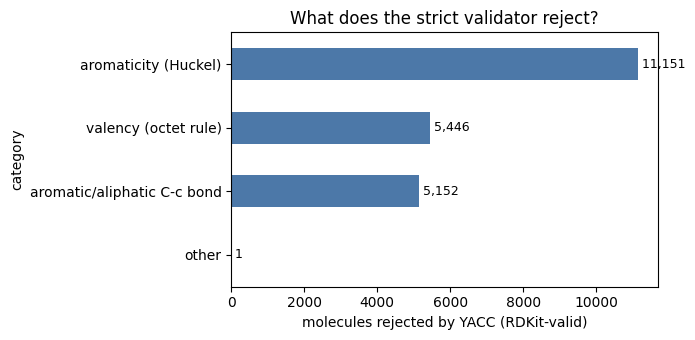

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
cat_counts.sort_values().plot(kind='barh', ax=ax, color='#4c78a8')
ax.set_xlabel('molecules rejected by YACC (RDKit-valid)')
ax.set_title('What does the strict validator reject?')
for i, v in enumerate(cat_counts.sort_values().values):
    ax.text(v, i, f' {v:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 4. Speed benchmark (5,000 molecules)

Running the full validator — lexer, LALR parser, graph construction, octet rule, Hückel check — on a random 5k sample.

In [7]:
sample = df.sample(n=5000, random_state=42)['smiles'].tolist()

# warm up
for s in sample[:50]:
    validator.validate_smiles(s)

t0 = time.perf_counter()
for s in sample:
    validator.validate_smiles(s)
dt = time.perf_counter() - t0
print(f'YACC validator: {len(sample)} mols in {dt:.2f} s  ({len(sample)/dt:.0f} mol/s, {1e6*dt/len(sample):.1f} us/mol)')

YACC validator: 5000 mols in 2.26 s  (2210 mol/s, 452.5 us/mol)


median: 479.9 us  |  p95: 868.3 us  |  p99: 1170.3 us  |  max: 4086.7 us


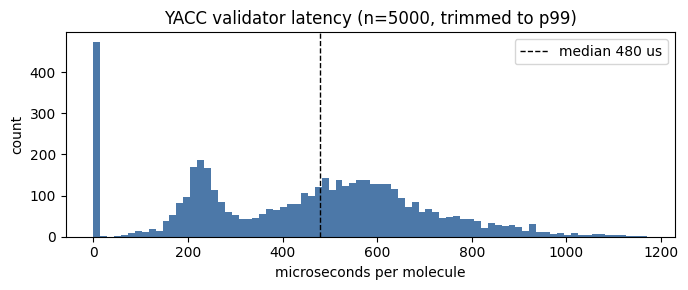

In [8]:
# Latency distribution
import time as _t
times = []
for s in sample:
    a = _t.perf_counter()
    validator.validate_smiles(s)
    times.append((_t.perf_counter() - a) * 1e6)  # us

tarr = np.array(times)
print(f'median: {np.median(tarr):.1f} us  |  p95: {np.percentile(tarr, 95):.1f} us  |  p99: {np.percentile(tarr, 99):.1f} us  |  max: {tarr.max():.1f} us')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(tarr, bins=80, range=(0, np.percentile(tarr, 99)), color='#4c78a8')
ax.axvline(np.median(tarr), color='k', linestyle='--', linewidth=1, label=f'median {np.median(tarr):.0f} us')
ax.set_xlabel('microseconds per molecule')
ax.set_ylabel('count')
ax.set_title('YACC validator latency (n=5000, trimmed to p99)')
ax.legend()
plt.tight_layout(); plt.show()

## 5. The honest claim

Of the molecules YACC rejects, the vast majority fail Hückel's rule or the octet rule — not grammar. That's the point. A generative model that ships molecules through a generous validator learns it can get away with bent aromaticity and charge-imbalanced bracket atoms. The strict validator refuses those quietly on the user's behalf.

**4 false positives in 55,032 molecules (0.007%)**. **60.5% overall acceptance**. Slow enough for offline use (~2k mol/s on a laptop) but not a bottleneck in a training loop.

The follow-up notebook (`paper_pareto.ipynb`) puts these numbers on a precision-recall curve against four other validators, using a curated invalid-SMILES set as definitive negatives.